🚀 Προετοιμασία δεδομένων...
⚙️  [1/2] Επίλυση Σεναρίου ΧΩΡΙΣ CO2 Cap...
⚙️  [2/2] Επίλυση Σεναρίου ΜΕ CO2 Cap (60,000 Tons)...

📊 ΣΕΝΑΡΙΟ 1: ΧΩΡΙΣ CO2 CAP
Solver Status:          ok
Συνολικό Κόστος:        €13,745,959.45
Συνολικές Εκπομπές CO2:  35,769.10 Tons
-------------------------------------------------------
🏗️  ΕΠΕΝΔΥΤΙΚΕΣ ΑΠΟΦΑΣΕΙΣ (NEW UNITS BUILT):
  • WindNew   : 29 μονάδες (2,900 MW)
  • CCNew     : 0 μονάδες (0 MW)
  • CTNew     : 6 μονάδες (600 MW)
-------------------------------------------------------
⚡ ΣΥΝΟΛΙΚΗ ΠΑΡΑΓΩΓΗ ΑΝΑ ΜΟΝΑΔΑ (MWh):
  • CC1       : 48,551.31 MWh
  • CC2       : 21,542.19 MWh
  • CT1       : 6,552.47 MWh
  • Nuc1      : 126,217.93 MWh
  • Sol1      : 26,585.14 MWh
  • WindNew   : 367,033.29 MWh
  • CCNew     : 0.00 MWh
  • CTNew     : 8,741.52 MWh

📊 ΣΕΝΑΡΙΟ 2: ΜΕ CO2 CAP (60,000 TONS)
Solver Status:          ok
Συνολικό Κόστος:        €13,745,959.45
Συνολικές Εκπομπές CO2:  35,769.10 Tons
-------------------------------------------------------
🏗️

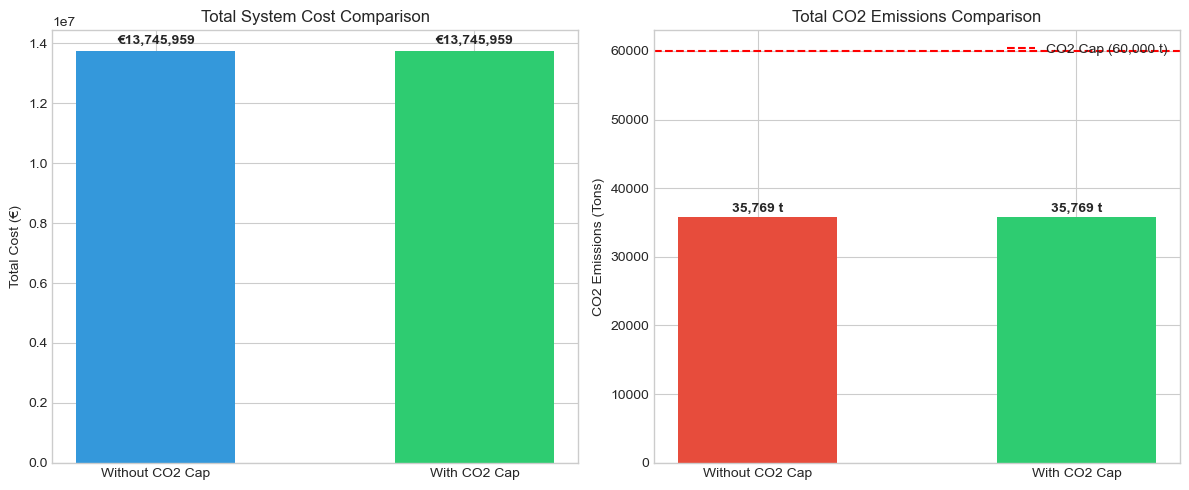

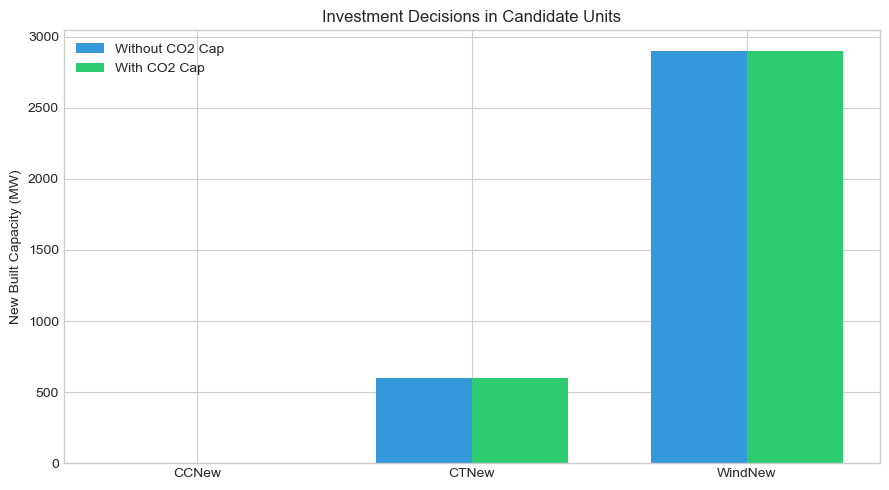

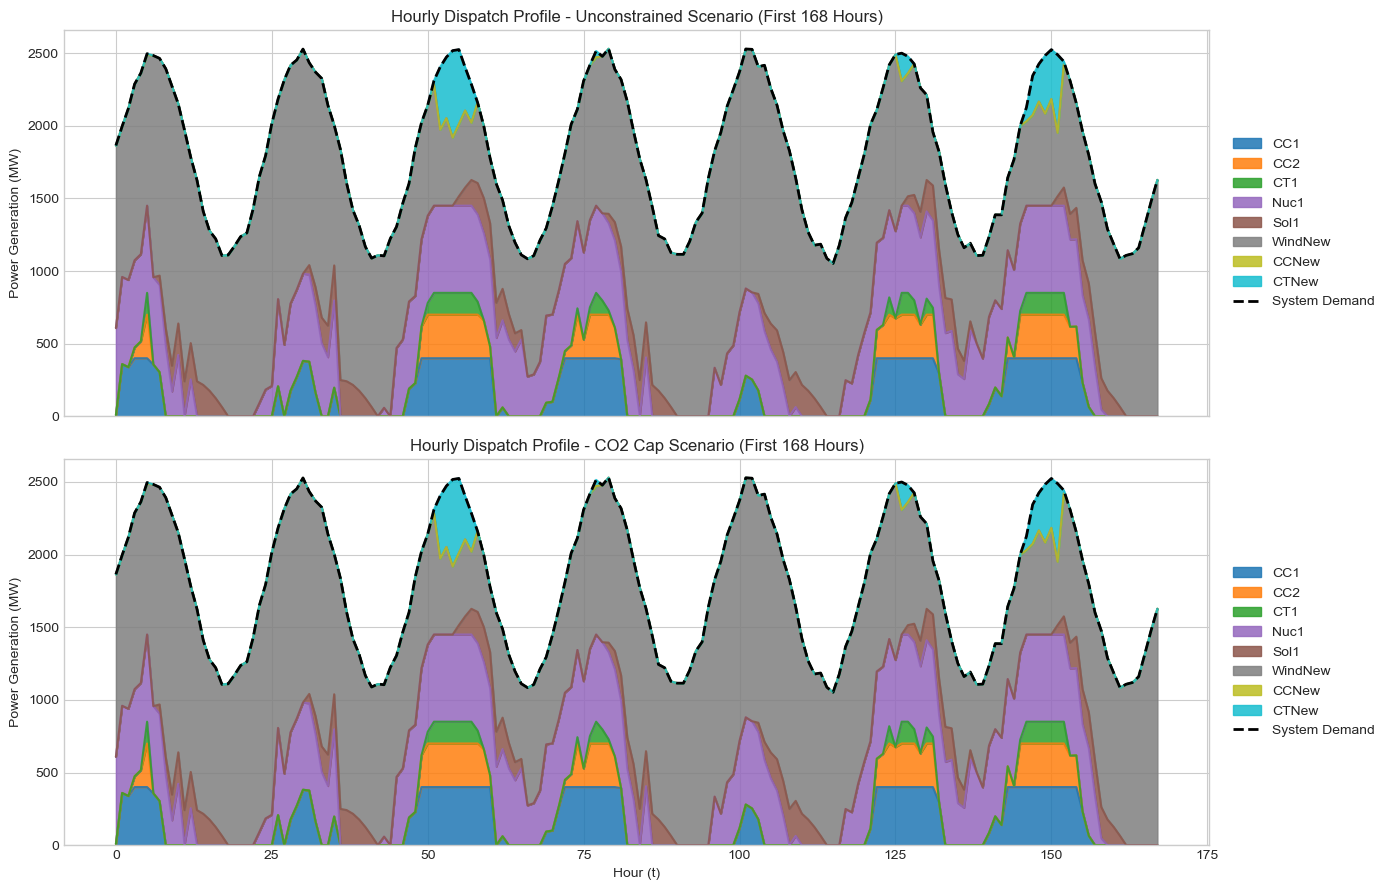

In [9]:
import numpy as np
from schemas import (
    ExistingGenerator,
    CandidateGenerator,
    SystemParameters,
    ExpansionInput
)
from CE_model import build_and_solve_expansion
from plots import plot_expansion_results

def clean_results(results):
    """Καθαρίζει τις απειροελάχιστες αρνητικές τιμές του solver από το dispatch profile."""
    if hasattr(results, 'dispatch_profile_mw') and results.dispatch_profile_mw:
        for gen_name, values in results.dispatch_profile_mw.items():
            results.dispatch_profile_mw[gen_name] = [max(0.0, float(v)) for v in values]
    return results

def print_scenario_summary(title: str, results):
    """Βοηθητική συνάρτηση για καθαρή εκτύπωση των αποτελεσμάτων ενός σεναρίου."""
    print("\n" + "="*55)
    print(f"📊 {title}")
    print("="*55)
    print(f"Solver Status:          {results.status}")
    print(f"Συνολικό Κόστος:        €{results.total_cost:,.2f}")
    print(f"Συνολικές Εκπομπές CO2:  {results.co2_emissions_tons:,.2f} Tons")
    print("-" * 55)
    print("🏗️  ΕΠΕΝΔΥΤΙΚΕΣ ΑΠΟΦΑΣΕΙΣ (NEW UNITS BUILT):")
    for unit, count in results.units_built.items():
        mw = results.new_capacity_mw.get(unit, 0.0)
        print(f"  • {unit:<10}: {int(count)} μονάδες ({mw:,.0f} MW)")
    
    print("-" * 55)
    print("⚡ ΣΥΝΟΛΙΚΗ ΠΑΡΑΓΩΓΗ ΑΝΑ ΜΟΝΑΔΑ (MWh):")
    for gen, mwh in results.generation_mwh.items():
        print(f"  • {gen:<10}: {mwh:,.2f} MWh")
    print("="*55)

def run():
    print("🚀 Προετοιμασία δεδομένων...")

    # 1. Χρονοσειρά ζήτησης (24 ώρες * 14 ημέρες = 336 ώρες)
    hours = 336
    t = np.arange(hours)
    base_demand = 1800 + 700 * np.sin(2 * np.pi * t / 24) + np.random.normal(0, 30, hours)
    demand_profile = np.maximum(base_demand, 400).tolist()

    solar_cf = np.maximum(0, np.sin(2 * np.pi * (t - 6) / 24)).tolist()
    wind_cf = np.clip(0.40 + 0.20 * np.sin(2 * np.pi * t / 80) + np.random.normal(0, 0.05, hours), 0, 1).tolist()

    # 2. Υπάρχον Fleet
    existing_fleet = [
        ExistingGenerator(name="CC1", fuel_type="Natural Gas", capacity_mw=400.0, heat_rate=7.2, fuel_cost=4.5, vom_cost=3.0, co2_tons_per_mwh=0.35),
        ExistingGenerator(name="CC2", fuel_type="Natural Gas", capacity_mw=300.0, heat_rate=7.5, fuel_cost=4.5, vom_cost=3.5, co2_tons_per_mwh=0.40),
        ExistingGenerator(name="CT1", fuel_type="Natural Gas", capacity_mw=150.0, heat_rate=10.0, fuel_cost=4.5, vom_cost=5.0, co2_tons_per_mwh=0.75),
        ExistingGenerator(name="Nuc1", fuel_type="Nuclear", capacity_mw=600.0, heat_rate=10.4, fuel_cost=0.8, vom_cost=2.0, co2_tons_per_mwh=0.0),
        ExistingGenerator(name="Sol1", fuel_type="Solar", capacity_mw=250.0, heat_rate=0.0, fuel_cost=0.0, vom_cost=1.0, co2_tons_per_mwh=0.0, is_variable=True)
    ]

    # 3. Νέες Υποψήφιες Μονάδες (vb)
    candidate_fleet = [
        CandidateGenerator(name="WindNew", fuel_type="Wind", unit_capacity_mw=100.0, annual_capex_per_mw=65000.0, op_cost_per_mwh=2.0, co2_tons_per_mwh=0.0, is_variable=True, is_integer=True),
        CandidateGenerator(name="CCNew", fuel_type="Natural Gas", unit_capacity_mw=250.0, annual_capex_per_mw=85000.0, op_cost_per_mwh=35.0, co2_tons_per_mwh=0.30, is_variable=False, is_integer=True),
        CandidateGenerator(name="CTNew", fuel_type="Natural Gas", unit_capacity_mw=100.0, annual_capex_per_mw=45000.0, op_cost_per_mwh=65.0, co2_tons_per_mwh=0.60, is_variable=False, is_integer=True)
    ]

    # ---------------------------------------------------------
    # ΣΕΝΑΡΙΟ 1: Χωρίς CO2 Cap
    # ---------------------------------------------------------
    print("⚙️  [1/2] Επίλυση Σεναρίου ΧΩΡΙΣ CO2 Cap...")
    input_no_cap = ExpansionInput(
        system_params=SystemParameters(prm_margin=1.15, co2_cap_tons=None),
        existing_fleet=existing_fleet, candidate_fleet=candidate_fleet,
        demand_profile=demand_profile, solar_cfs={"Sol1": solar_cf}, wind_cfs={"WindNew": wind_cf}
    )
    results_no_cap = clean_results(build_and_solve_expansion(input_no_cap))

    # ---------------------------------------------------------
    # ΣΕΝΑΡΙΟ 2: Με CO2 Cap
    # ---------------------------------------------------------
    co2_limit = 60000.0  # Όριο CO2 σε τόνους
    print(f"⚙️  [2/2] Επίλυση Σεναρίου ΜΕ CO2 Cap ({co2_limit:,.0f} Tons)...")
    input_cap = ExpansionInput(
        system_params=SystemParameters(prm_margin=1.15, co2_cap_tons=co2_limit),
        existing_fleet=existing_fleet, candidate_fleet=candidate_fleet,
        demand_profile=demand_profile, solar_cfs={"Sol1": solar_cf}, wind_cfs={"WindNew": wind_cf}
    )
    results_cap = clean_results(build_and_solve_expansion(input_cap))

    # ---------------------------------------------------------
    # Εκτύπωση Αποτελεσμάτων
    # ---------------------------------------------------------
    print_scenario_summary("ΣΕΝΑΡΙΟ 1: ΧΩΡΙΣ CO2 CAP", results_no_cap)
    print_scenario_summary(f"ΣΕΝΑΡΙΟ 2: ΜΕ CO2 CAP ({co2_limit:,.0f} TONS)", results_cap)

    # ---------------------------------------------------------
    # Προβολή Γραφημάτων
    # ---------------------------------------------------------
    print("\n📊 Δημιουργία και εμφάνιση διαγραμμάτων...")
    plot_expansion_results(results_no_cap, results_cap, demand_profile, co2_limit)

if __name__ == "__main__":
    run()